# Določevanje razpoloženja (sentimenta)

## Namestitev programskih modulov

In [1]:
!pip install transformers
!pip install python-docx
!pip install ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 244.3/244.3 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 43.0 MB/s eta 0:00:00


## Priklic programskih modulov

In [7]:
from transformers import pipeline
from docx import Document
import re


## Priklic besedila

In [9]:
# Naloži dokument
file_path = '/content/Antrittsrede_von_Donald_Trump_englisch.docx'
# file_path = r"data\Trump_inauguration\Antrittsrede_von_Donald_Trump_englisch.docx"
doc = Document(file_path)


## Priprava besedila

V prvem koraku pridobimo besedilo iz naložene Wordove datoteke.

V drugem koraku razdelimo besedilo na povedi. Merilo segmentacije so končna ločila. Pri tem opravilu nam pomagajo regularni izrazi.

In [10]:
# Izvleči besedilo iz dokumenta
text = "\n".join([p.text for p in doc.paragraphs if p.text.strip()])
sentences = re.split(r'(?<=[.!?]) +', text)


## Priklic sentimentnega modela

In [11]:
# Naloži model sentimentne analize
sentiment_analysis = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/841 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

Device set to use cuda:0


## Analiza besedila

In [12]:
# Analiziraj sentiment posamezne povedi
results = [{"sentence": sentence, "sentiment": sentiment_analysis(sentence)[0]} for sentence in sentences]


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


## Prikaz izidov

In [13]:
# Prikaži rezultate
for result in results:
    print(f"Sentence: {result['sentence']}")
    print(f"Sentiment: {result['sentiment']['label']} (Score: {result['sentiment']['score']})\n")


Sentence: It is my honor and pleasure to introduce to you the 45th and the 47th President of the United States of America, Donald J.
Sentiment: positive (Score: 0.8757715821266174)

Sentence: Trump.
Sentiment: negative (Score: 0.41945314407348633)

Sentence: Thank you very much, everybody.
Sentiment: positive (Score: 0.9117686748504639)

Sentence: Well, thank you very, very much.
Sentiment: positive (Score: 0.8509616255760193)

Sentence: Vice President Vance, Speaker Johnson, Senator Thune, Chief Justice Roberts, Justices of the United States Supreme Court, President Clinton, President Bush, President Obama, President Biden, Vice President Harris, and my fellow citizens.
Sentiment: neutral (Score: 0.6428964138031006)

Sentence: Thank you.
Sentiment: positive (Score: 0.8660823106765747)

Sentence: The golden age of America begins right now.
Sentiment: positive (Score: 0.7755903005599976)

Sentence: From this day forward, our country will flourish and be respected again all over the worl

### Naredi preglednico

In [15]:
# prompt: Naredi tabelo (dataframe) iz "results", in sicer s stolpci sentence, label in score.

import pandas as pd
df_results = pd.DataFrame([
    {'sentence': result['sentence'], 'label': result['sentiment']['label'], 'score': result['sentiment']['score']}
    for result in results
])

df_results

,sentence,label,score
0,It is my honor and pleasure to introduce to yo...,positive,0.875772
1,Trump.,negative,0.419453
2,"Thank you very much, everybody.",positive,0.911769
3,"Well, thank you very, very much.",positive,0.850962
4,"Vice President Vance, Speaker Johnson, Senator...",neutral,0.642896
...,...,...,...
186,"The future is ours, and our golden age has jus...",positive,0.595344
187,Thank you.,positive,0.866082
188,God bless America.,positive,0.853147
189,Thank you all.,positive,0.891367


<ipython-input-16-dd46ffd254b0>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df_results, x='score', y='label', inner='stick', palette='Dark2')


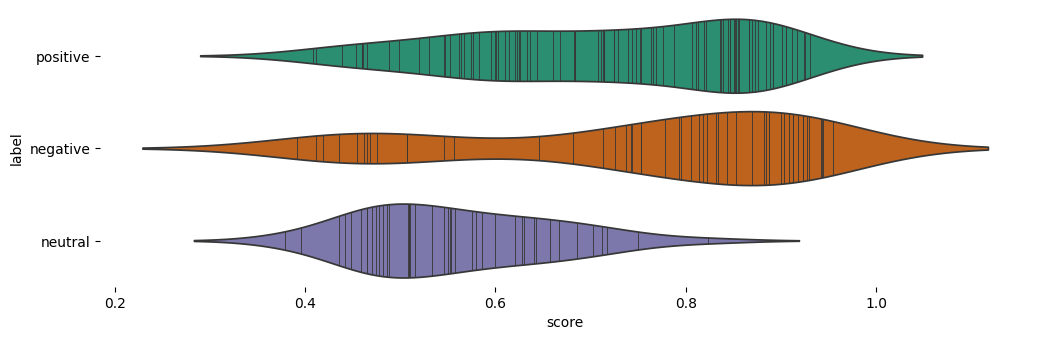

In [16]:
# @title label vs score

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df_results['label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_results, x='score', y='label', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [24]:
# prompt: Naloži podnapise iz datoteke "/content/AI company's CEO issues warning about mass unemployment_en.srt", odstrani številke podnapisov, timecode in prazne vrstice, tako da bo vsaka poved (ki se konča s piko, klicajem ali vprašajem) v svoji vrstici. Zamenjaj \n ali več zaporednih \n s presledkom, če ni končega ločila (pika, klicaj, vprašaj).

import re

def process_srt(filepath):
    """
    Processes an SRT file:
    - Removes subtitle numbers, timecodes, and empty lines.
    - Joins lines within a subtitle block that don't end with punctuation.
    - Keeps each sentence (ending with ., !, ?) on a new line.

    Args:
        filepath (str): The path to the SRT file.

    Returns:
        str: The processed text with one sentence per line.
    """
    with open(filepath, 'r', encoding='utf-8') as f:
        content = f.read()

    # Remove subtitle numbers, timecodes, and empty lines between blocks
    # This regex matches a block starting with a number, followed by timecode and then lines until a blank line
    cleaned_content = re.sub(r'\d+\n[\d:,\-\s>]*\n', '', content, flags=re.MULTILINE)

    # Replace internal \n or multiple consecutive \n not followed by a sentence ender with a space
    # This handles line breaks within a single spoken utterance in the SRT
    cleaned_content = re.sub(r'\n(?![\.\!\?])', ' ', cleaned_content)
    # Replace multiple spaces with a single space
    cleaned_content = re.sub(r' +', ' ', cleaned_content)
    # Trim leading/trailing whitespace from lines
    cleaned_content = '\n'.join([line.strip() for line in cleaned_content.split('\n')])
    # Remove any remaining empty lines
    cleaned_content = '\n'.join([line for line in cleaned_content.split('\n') if line])


    # Split into sentences based on ., !, ?
    # Ensure we keep the delimiter with the sentence
    sentences = re.findall(r'[^.!?]+[.!?]', cleaned_content)

    # Join sentences back with a newline
    processed_text = "\n".join(sentences)

    return processed_text

srt_filepath = "/content/AI company's CEO issues warning about mass unemployment_en.srt"
processed_subtitle_text = process_srt(srt_filepath)

# Print the processed text
processed_subtitle_text


"Well known, respected tech CEO Dario Amodei, who heads a cutting edge AI company called anthropic, is raising alarms tonight about AI's potential impact on employment that could soon be felt.\n Well, he says, I can lead to incredible advancements like medical breakthroughs and boost the economy.\n He believes it could also lead to half of entry level white collar jobs, disappearing in to 20% unemployment in the next 1 to 5 years.\n It's something that's been talked about within tech circles for a while, but rarely so starkly and so publicly.\n I spoke to him just before er about that and other implications he thinks I may have on society.\n Dario, you've said that I could wipe out half of all entry level white collar jobs and spike unemployment to 10 to 20%.\n How soon might that happen?\n Well, let's, first of all, thanks for having me on the show.\n But, just to back up a little bit, you know, I've been building AI for over a decade, and I think maybe the most salient feature, the t

In [45]:
sentences2 = re.split(r'(?<=[.!?]) +', processed_subtitle_text)
sentences2

["Well known, respected tech CEO Dario Amodei, who heads a cutting edge AI company called anthropic, is raising alarms tonight about AI's potential impact on employment that could soon be felt.\n Well, he says, I can lead to incredible advancements like medical breakthroughs and boost the economy.\n He believes it could also lead to half of entry level white collar jobs, disappearing in to 20% unemployment in the next 1 to 5 years.\n It's something that's been talked about within tech circles for a while, but rarely so starkly and so publicly.\n I spoke to him just before er about that and other implications he thinks I may have on society.\n Dario, you've said that I could wipe out half of all entry level white collar jobs and spike unemployment to 10 to 20%.\n How soon might that happen?\n Well, let's, first of all, thanks for having me on the show.\n But, just to back up a little bit, you know, I've been building AI for over a decade, and I think maybe the most salient feature, the 

In [50]:
# prompt: Uporabi \n iz sentences2 za razdelitev povedi!

sentences2 = processed_subtitle_text.split('\n')
sentences2

["Well known, respected tech CEO Dario Amodei, who heads a cutting edge AI company called anthropic, is raising alarms tonight about AI's potential impact on employment that could soon be felt.",
 ' Well, he says, I can lead to incredible advancements like medical breakthroughs and boost the economy.',
 ' He believes it could also lead to half of entry level white collar jobs, disappearing in to 20% unemployment in the next 1 to 5 years.',
 " It's something that's been talked about within tech circles for a while, but rarely so starkly and so publicly.",
 ' I spoke to him just before er about that and other implications he thinks I may have on society.',
 " Dario, you've said that I could wipe out half of all entry level white collar jobs and spike unemployment to 10 to 20%.",
 ' How soon might that happen?',
 " Well, let's, first of all, thanks for having me on the show.",
 " But, just to back up a little bit, you know, I've been building AI for over a decade, and I think maybe the mo

In [51]:
# shorten the first sentence in sentences2
if sentences2 and len(sentences2) > 0:
    original_first_sentence = sentences2[0]
    # Truncate the first sentence to a manageable length (e.g., first 500 characters)
    # This is a simple fix for this specific long sentence.
    # A more general solution would involve splitting long sentences.
    truncated_first_sentence = original_first_sentence[:500]
    sentences2[0] = truncated_first_sentence
    print(f"Original first sentence (truncated for processing): {original_first_sentence[:100]}...")
    print(f"Truncated first sentence: {sentences2[0][:100]}...")

# The rest of your analysis code using the (potentially modified) sentences2 list
# Priklic sentimentnega modela
# Naloži model sentimentne analize
sentiment_analysis = pipeline("sentiment-analysis", model="cardiffnlp/twitter-xlm-roberta-base-sentiment")

# Get the tokenizer from the pipeline for a more accurate length check
tokenizer = sentiment_analysis.tokenizer

# Analiziraj sentiment posamezne povedi
results2 = []
# Maximum sequence length for the model (typically 512 for XLM-RoBERTa Base)
# We'll subtract a small buffer for special tokens ([CLS], [SEP])
max_model_input_length = tokenizer.model_max_length if hasattr(tokenizer, 'model_max_length') else 512 - 2


for sentence in sentences2:
    # Ensure sentence is not empty before tokenizing and processing
    if not sentence or not sentence.strip():
        continue # Skip empty or whitespace-only strings

    try:
        # Check token length using the tokenizer
        tokenized_sentence = tokenizer(sentence, add_special_tokens=False)
        sentence_length_in_tokens = len(tokenized_sentence['input_ids'])

        if sentence_length_in_tokens > max_model_input_length:
            print(f"Skipping long sentence (token length {sentence_length_in_tokens} > {max_model_input_length}): {sentence[:100]}...") # Print a snippet
            # Append the skipped result and continue to the next sentence
            results2.append({"sentence": sentence, "sentiment": {"label": "SKIPPED_TOO_LONG", "score": 0.0}})
            continue # Skip the sentiment analysis for this long sentence

        # If the sentence is not too long, perform sentiment analysis
        results2.append({"sentence": sentence, "sentiment": sentiment_analysis(sentence)[0]})

    except Exception as e:
        # Catch other potential errors during sentiment analysis for valid-length sentences
        print(f"Error processing sentence: {sentence[:100]}... Error: {e}")
        results2.append({"sentence": sentence, "sentiment": {"label": "ERROR_PROCESSING", "score": 0.0}})

Original first sentence (truncated for processing): Well known, respected tech CEO Dario Amodei, who heads a cutting edge AI company called anthropic, i...
Truncated first sentence: Well known, respected tech CEO Dario Amodei, who heads a cutting edge AI company called anthropic, i...


Device set to use cuda:0


In [52]:
results2

[{'sentence': "Well known, respected tech CEO Dario Amodei, who heads a cutting edge AI company called anthropic, is raising alarms tonight about AI's potential impact on employment that could soon be felt.",
  'sentiment': {'label': 'positive', 'score': 0.6959304809570312}},
 {'sentence': ' Well, he says, I can lead to incredible advancements like medical breakthroughs and boost the economy.',
  'sentiment': {'label': 'positive', 'score': 0.834479033946991}},
 {'sentence': ' He believes it could also lead to half of entry level white collar jobs, disappearing in to 20% unemployment in the next 1 to 5 years.',
  'sentiment': {'label': 'negative', 'score': 0.5371079444885254}},
 {'sentence': " It's something that's been talked about within tech circles for a while, but rarely so starkly and so publicly.",
  'sentiment': {'label': 'neutral', 'score': 0.5303942561149597}},
 {'sentence': ' I spoke to him just before er about that and other implications he thinks I may have on society.',
  

In [53]:
# prompt: Naredi tabelo (dataframe) iz "results2", in sicer s stolpci sentence, label in score.

import pandas as pd
df_results2 = pd.DataFrame([
    {'sentence': result['sentence'], 'label': result['sentiment']['label'], 'score': result['sentiment']['score']}
    for result in results2
])

df_results2

,sentence,label,score
0,"Well known, respected tech CEO Dario Amodei, w...",positive,0.695930
1,"Well, he says, I can lead to incredible advan...",positive,0.834479
2,He believes it could also lead to half of ent...,negative,0.537108
3,It's something that's been talked about withi...,neutral,0.530394
4,I spoke to him just before er about that and ...,neutral,0.771931
...,...,...,...
134,"And, you know, I think it shouldn't be a Part...",negative,0.653911
135,"Dario, thank you so much.",positive,0.912598
136,It's really fascinating.,positive,0.874345
137,Yeah.,neutral,0.543900


<ipython-input-54-1fa87cb80c82>:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(df_results2, x='score', y='label', inner='stick', palette='Dark2')


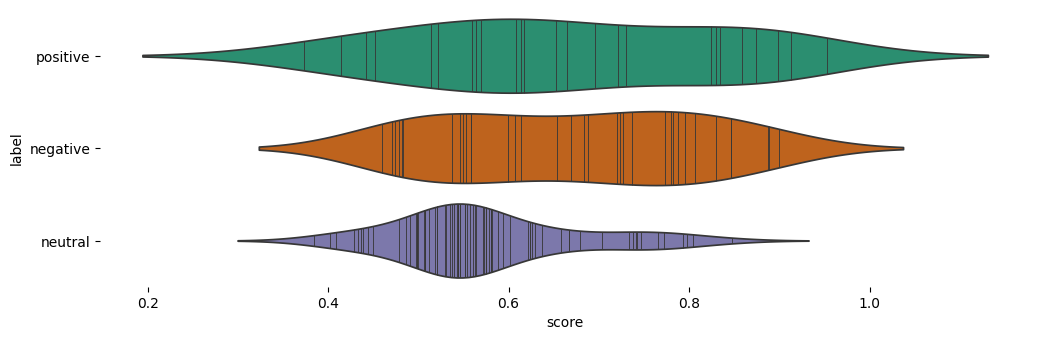

In [54]:
# @title label vs score

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df_results2['label'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_results2, x='score', y='label', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

In [60]:
# prompt: Združi results in results2 v en dataframe, dodaj stolpec z imenom vsakega izmed obeh besedil.

import pandas as pd
import matplotlib.pyplot as plt
# Add a source column to each DataFrame
df_results['source'] = 'Trump Speech'
df_results2['source'] = 'AI CEO Warning'

# Concatenate the two dataframes
combined_df = pd.concat([df_results, df_results2], ignore_index=True)
# Display the combined dataframe
print(combined_df.head())
print(combined_df.tail())


                                            sentence     label     score  \
0  It is my honor and pleasure to introduce to yo...  positive  0.875772   
1                                             Trump.  negative  0.419453   
2                    Thank you very much, everybody.  positive  0.911769   
3                   Well, thank you very, very much.  positive  0.850962   
4  Vice President Vance, Speaker Johnson, Senator...   neutral  0.642896   

         source  
0  Trump Speech  
1  Trump Speech  
2  Trump Speech  
3  Trump Speech  
4  Trump Speech  
                                              sentence     label     score  \
325   And, you know, I think it shouldn't be a Part...  negative  0.653911   
326                          Dario, thank you so much.  positive  0.912598   
327                           It's really fascinating.  positive  0.874345   
328                                              Yeah.   neutral  0.543900   
329                 thank you for having me, 

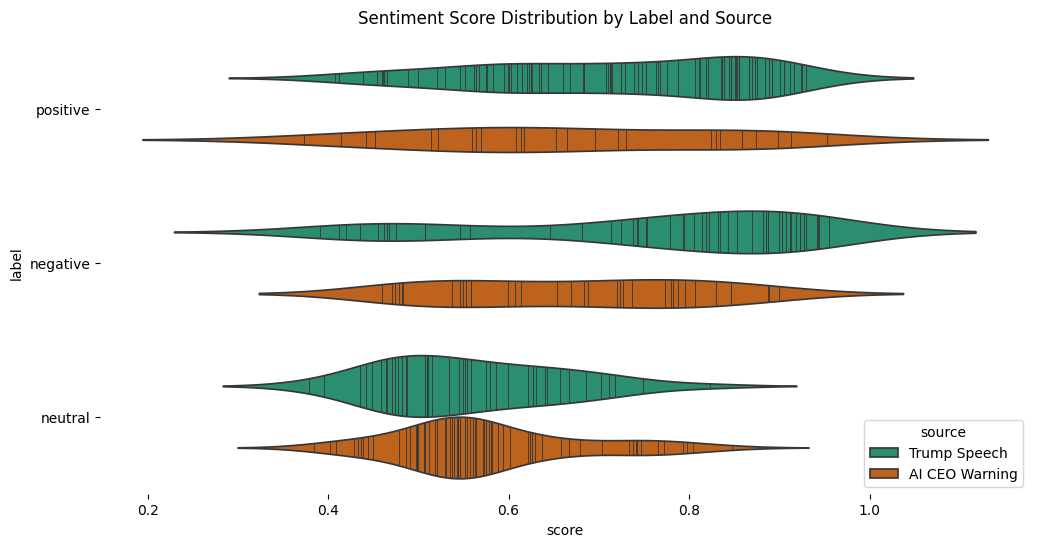

In [59]:
# Optional: You can now analyze or visualize the combined_df
# For example, plotting sentiment scores by source
plt.figure(figsize=(12, 6))
sns.violinplot(combined_df, x='score', y='label', hue='source', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)
plt.title('Sentiment Score Distribution by Label and Source')
plt.show()

## Kruskal-Wallis-Test

In [62]:
# prompt: Izračunaj povprečen score pozitivnega sentimenta za vsako besedilo in izvedi kruskal-wallis test!

from scipy import stats

# Filter for positive sentiment scores
positive_scores_trump = combined_df[(combined_df['source'] == 'Trump Speech') & (combined_df['label'] == 'positive')]['score']
positive_scores_ai_ceo = combined_df[(combined_df['source'] == 'AI CEO Warning') & (combined_df['label'] == 'positive')]['score']

# Calculate the average positive sentiment score for each text
average_positive_score_trump = positive_scores_trump.mean() if not positive_scores_trump.empty else 0
average_positive_score_ai_ceo = positive_scores_ai_ceo.mean() if not positive_scores_ai_ceo.empty else 0

print(f"Povprečen score pozitivnega sentimenta za Trumpov govor: {average_positive_score_trump:.4f}")
print(f"Povprečen score pozitivnega sentimenta za opozorilo direktorja AI podjetja: {average_positive_score_ai_ceo:.4f}")


# Perform Kruskal-Wallis test on positive sentiment scores
# Kruskal-Wallis H-test requires at least two groups and each group must have at least 5 observations
if len(positive_scores_trump) >= 5 and len(positive_scores_ai_ceo) >= 5:
    kruskal_h, kruskal_p = stats.kruskal(positive_scores_trump, positive_scores_ai_ceo)

    print("\nRezultati Kruskal-Wallis testa za pozitivne sentimente:")
    print(f"H statistika: {kruskal_h:.4f}")
    print(f"P-vrednost: {kruskal_p:.4f}")

    # Interpret the result
    alpha = 0.05
    if kruskal_p < alpha:
        print(f"Statistično značilna razlika (p < {alpha:.2f}) med distribucijami pozitivnega sentimenta med besediloma.")
    else:
        print(f"Ni statistično značilne razlike (p >= {alpha:.2f}) med distribucijami pozitivnega sentimenta med besediloma.")
else:
    print("\nZa izvedbo Kruskal-Wallis testa je potrebnih vsaj 5 pozitivnih sentimentnih ocen v vsaki skupini.")
    print(f"Število pozitivnih ocen za Trumpov govor: {len(positive_scores_trump)}")
    print(f"Število pozitivnih ocen za opozorilo AI CEO: {len(positive_scores_ai_ceo)}")


Povprečen score pozitivnega sentimenta za Trumpov govor: 0.7210
Povprečen score pozitivnega sentimenta za opozorilo direktorja AI podjetja: 0.6680

Rezultati Kruskal-Wallis testa za pozitivne sentimente:
H statistika: 2.1124
P-vrednost: 0.1461
Ni statistično značilne razlike (p >= 0.05) med distribucijami pozitivnega sentimenta med besediloma.


In [63]:
# prompt: Izračunaj povprečen score negativnega sentimenta za vsako besedilo in izvedi kruskal-wallis test!

# Filter for negative sentiment scores
negative_scores_trump = combined_df[(combined_df['source'] == 'Trump Speech') & (combined_df['label'] == 'negative')]['score']
negative_scores_ai_ceo = combined_df[(combined_df['source'] == 'AI CEO Warning') & (combined_df['label'] == 'negative')]['score']

# Calculate the average negative sentiment score for each text
average_negative_score_trump = negative_scores_trump.mean() if not negative_scores_trump.empty else 0
average_negative_score_ai_ceo = negative_scores_ai_ceo.mean() if not negative_scores_ai_ceo.empty else 0

print(f"Povprečen score negativnega sentimenta za Trumpov govor: {average_negative_score_trump:.4f}")
print(f"Povprečen score negativnega sentimenta za opozorilo direktorja AI podjetja: {average_negative_score_ai_ceo:.4f}")

# Perform Kruskal-Wallis test on negative sentiment scores
# Kruskal-Wallis H-test requires at least two groups and each group must have at least 5 observations
if len(negative_scores_trump) >= 5 and len(negative_scores_ai_ceo) >= 5:
    kruskal_h_neg, kruskal_p_neg = stats.kruskal(negative_scores_trump, negative_scores_ai_ceo)

    print("\nRezultati Kruskal-Wallis testa za negativne sentimente:")
    print(f"H statistika: {kruskal_h_neg:.4f}")
    print(f"P-vrednost: {kruskal_p_neg:.4f}")

    # Interpret the result
    alpha = 0.05
    if kruskal_p_neg < alpha:
        print(f"Statistično značilna razlika (p < {alpha:.2f}) med distribucijami negativnega sentimenta med besediloma.")
    else:
        print(f"Ni statistično značilne razlike (p >= {alpha:.2f}) med distribucijami negativnega sentimenta med besediloma.")
else:
    print("\nZa izvedbo Kruskal-Wallis testa za negativne sentimente je potrebnih vsaj 5 negativnih sentimentnih ocen v vsaki skupini.")
    print(f"Število negativnih ocen za Trumpov govor: {len(negative_scores_trump)}")
    print(f"Število negativnih ocen za opozorilo AI CEO: {len(negative_scores_ai_ceo)}")

Povprečen score negativnega sentimenta za Trumpov govor: 0.7521
Povprečen score negativnega sentimenta za opozorilo direktorja AI podjetja: 0.6714

Rezultati Kruskal-Wallis testa za negativne sentimente:
H statistika: 6.2613
P-vrednost: 0.0123
Statistično značilna razlika (p < 0.05) med distribucijami negativnega sentimenta med besediloma.


In [64]:
# prompt: Izračunaj povprečen score neutralnega sentimenta za vsako besedilo in izvedi kruskal-wallis test!

# Filter for neutral sentiment scores
neutral_scores_trump = combined_df[(combined_df['source'] == 'Trump Speech') & (combined_df['label'] == 'neutral')]['score']
neutral_scores_ai_ceo = combined_df[(combined_df['source'] == 'AI CEO Warning') & (combined_df['label'] == 'neutral')]['score']

# Calculate the average neutral sentiment score for each text
average_neutral_score_trump = neutral_scores_trump.mean() if not neutral_scores_trump.empty else 0
average_neutral_score_ai_ceo = neutral_scores_ai_ceo.mean() if not neutral_scores_ai_ceo.empty else 0

print(f"Povprečen score neutralnega sentimenta za Trumpov govor: {average_neutral_score_trump:.4f}")
print(f"Povprečen score neutralnega sentimenta za opozorilo direktorja AI podjetja: {average_neutral_score_ai_ceo:.4f}")

# Perform Kruskal-Wallis test on neutral sentiment scores
# Kruskal-Wallis H-test requires at least two groups and each group must have at least 5 observations
if len(neutral_scores_trump) >= 5 and len(neutral_scores_ai_ceo) >= 5:
    kruskal_h_neu, kruskal_p_neu = stats.kruskal(neutral_scores_trump, neutral_scores_ai_ceo)

    print("\nRezultati Kruskal-Wallis testa za nevtralne sentimente:")
    print(f"H statistika: {kruskal_h_neu:.4f}")
    print(f"P-vrednost: {kruskal_p_neu:.4f}")

    # Interpret the result
    alpha = 0.05
    if kruskal_p_neu < alpha:
        print(f"Statistično značilna razlika (p < {alpha:.2f}) med distribucijami nevtralnega sentimenta med besediloma.")
    else:
        print(f"Ni statistično značilne razlike (p >= {alpha:.2f}) med distribucijami nevtralnega sentimenta med besediloma.")
else:
    print("\nZa izvedbo Kruskal-Wallis testa za nevtralne sentimente je potrebnih vsaj 5 nevtralnih sentimentnih ocen v vsaki skupini.")
    print(f"Število nevtralnih ocen za Trumpov govor: {len(neutral_scores_trump)}")
    print(f"Število nevtralnih ocen za opozorilo AI CEO: {len(neutral_scores_ai_ceo)}")

Povprečen score neutralnega sentimenta za Trumpov govor: 0.5579
Povprečen score neutralnega sentimenta za opozorilo direktorja AI podjetja: 0.5753

Rezultati Kruskal-Wallis testa za nevtralne sentimente:
H statistika: 0.8072
P-vrednost: 0.3689
Ni statistično značilne razlike (p >= 0.05) med distribucijami nevtralnega sentimenta med besediloma.


In [66]:
# prompt: Preštej, koliko je pozitivno, nevtralno in negativno ocenjenih povedi v vsakem besedilu in izvedi Hi-kvadrat test, da bi ugotovili, ali je med besediloma statistično značilna razlika v razmerju sentimentnih kategorij!

import pandas as pd
import matplotlib.pyplot as plt
# Štetje sentimentnih kategorij za vsako besedilo
sentiment_counts_trump = df_results['label'].value_counts().reindex(['positive', 'neutral', 'negative'], fill_value=0)
sentiment_counts_ai_ceo = df_results2['label'].value_counts().reindex(['positive', 'neutral', 'negative'], fill_value=0)

print("Število povedi po sentimentu za Trumpov govor:")
print(sentiment_counts_trump)
print("\nŠtevilo povedi po sentimentu za opozorilo direktorja AI podjetja:")
print(sentiment_counts_ai_ceo)

# Priprava podatkov za Hi-kvadrat test
# Ustvarimo opazovane frekvence v obliki 2x3 tabele (Besedilo x Sentiment)
observed = pd.DataFrame({
    'Trump Speech': sentiment_counts_trump,
    'AI CEO Warning': sentiment_counts_ai_ceo
})
observed = observed.T # Prestavimo vrstice in stolpce, da imamo besedila kot vrstice in sentimente kot stolpce

print("\nOpazovane frekvence:")
print(observed)

# Izvedba Hi-kvadrat testa neodvisnosti
# Test preveri, ali obstaja statistično značilna povezava med besedilom in sentimentno kategorijo
chi2_stat, p_value, dof, expected = stats.chi2_contingency(observed)

print("\nRezultati Hi-kvadrat testa:")
print(f"Hi-kvadrat statistika: {chi2_stat:.4f}")
print(f"P-vrednost: {p_value:.4f}")
print(f"Stopnje prostosti (dof): {dof}")
print("\nPričakovane frekvence:")
print(pd.DataFrame(expected, index=observed.index, columns=observed.columns))

# Interpretacija rezultata
alpha = 0.05
if p_value < alpha:
    print(f"\nStatistično značilna razlika (p < {alpha:.2f}) v razmerju sentimentnih kategorij med besediloma.")
else:
    print(f"\nNi statistično značilne razlike (p >= {alpha:.2f}) v razmerju sentimentnih kategorij med besediloma.")


Število povedi po sentimentu za Trumpov govor:
label
positive    96
neutral     42
negative    53
Name: count, dtype: int64

Število povedi po sentimentu za opozorilo direktorja AI podjetja:
label
positive    25
neutral     79
negative    35
Name: count, dtype: int64

Opazovane frekvence:
label           positive  neutral  negative
Trump Speech          96       42        53
AI CEO Warning        25       79        35

Rezultati Hi-kvadrat testa:
Hi-kvadrat statistika: 49.6971
P-vrednost: 0.0000
Stopnje prostosti (dof): 2

Pričakovane frekvence:
label            positive    neutral   negative
Trump Speech    70.033333  70.033333  50.933333
AI CEO Warning  50.966667  50.966667  37.066667

Statistično značilna razlika (p < 0.05) v razmerju sentimentnih kategorij med besediloma.


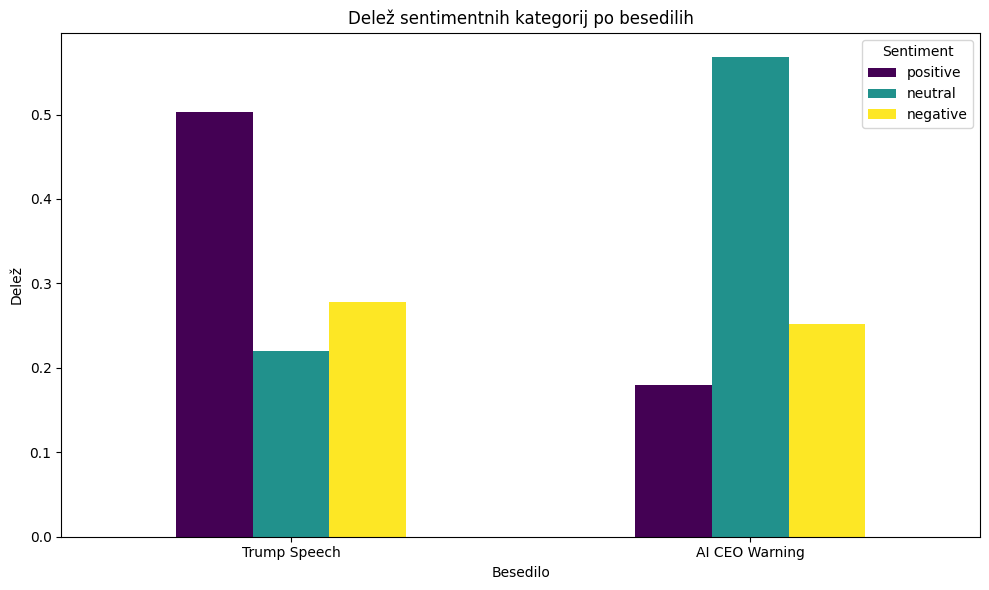

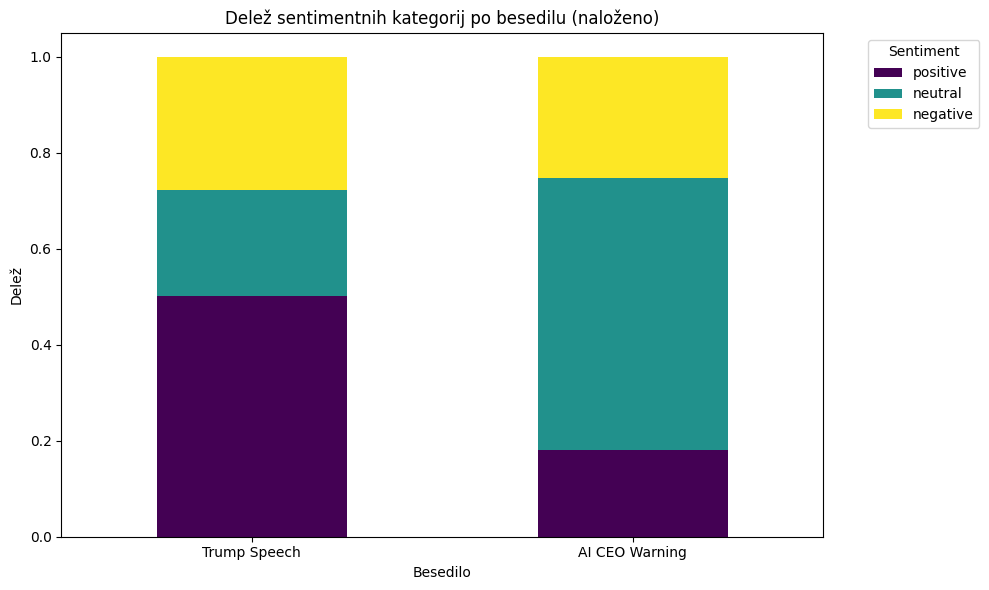

In [67]:
# Dodatna vizualizacija - Prikaz deležev sentimentov po besedilih
sentiment_proportions_trump = sentiment_counts_trump / sentiment_counts_trump.sum()
sentiment_proportions_ai_ceo = sentiment_counts_ai_ceo / sentiment_counts_ai_ceo.sum()

proportions_df = pd.DataFrame({
    'Trump Speech': sentiment_proportions_trump,
    'AI CEO Warning': sentiment_proportions_ai_ceo
})

proportions_df.T.plot(kind='bar', stacked=False, figsize=(10, 6), colormap='viridis')
plt.title('Delež sentimentnih kategorij po besedilih')
plt.xlabel('Besedilo')
plt.ylabel('Delež')
plt.xticks(rotation=0)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

# Prikaz deležev sentimentov po besedilih (stacked bar chart za primerjavo razmerij)
proportions_df.T.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis')
plt.title('Delež sentimentnih kategorij po besedilu (naloženo)')
plt.xlabel('Besedilo')
plt.ylabel('Delež')
plt.xticks(rotation=0)
plt.legend(title='Sentiment', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Is there a better way to compare the sentiment of both texts?

Yes, you are already using several good methods to compare the sentiment of the two texts:

1.  **Individual Sentence Sentiment Analysis:** You process each sentence and get its sentiment label and score. This provides a granular view.
2.  **DataFrame Creation:** You organize the results into pandas DataFrames (`df_results`, `df_results2`, `combined_df`), which is essential for analysis and visualization.
3.  **Visualization (Violin Plots):** Violin plots are excellent for showing the distribution of sentiment scores for each label and comparing distributions across the two sources. This gives a visual sense of how the scores vary.
4.  **Statistical Tests (Kruskal-Wallis and Chi-Squared):**
    *   **Kruskal-Wallis:** Appropriately used to compare the *distributions* of sentiment scores (positive, negative, neutral) between the two texts. This non-parametric test is suitable for comparing score distributions, especially if they aren't normally distributed.
    *   **Chi-Squared:** Correctly used to compare the *proportions* or counts of sentences falling into each sentiment category (positive, neutral, negative) between the two texts. This tests if the observed frequencies are independent of the text source.
5.  **Average Score Calculation:** Calculating the average scores for each sentiment label gives a simple summary statistic.
6.  **Count and Proportion Display:** Showing the raw counts and proportions of each sentiment category provides clear descriptive statistics.
7.  **Visualization (Bar Charts):** Bar charts (both grouped and stacked) are good for comparing the counts or proportions of sentiment categories directly between the two texts.

**Possible Enhancements or Alternative Approaches:**

While your current approach is comprehensive, here are a few potential additions or considerations depending on your specific goals:

*   **Lexical Diversity/Word Choice:** Are certain words or phrases more common in one text compared to the other, and how do those relate to sentiment? You could use techniques like TF-IDF or simple word frequency analysis to identify distinguishing terms.
*   **Sentiment Over Time/Progression:** If the order of sentences matters (e.g., how the sentiment changes throughout the speech/warning), you could plot the sentiment score or label sequentially. This requires preserving the original order.
*   **Topic Modeling:** What are the main topics discussed in each text, and how does the sentiment vary *within* those topics? Techniques like LDA (Latent Dirichlet Allocation) could be used.
*   **Comparing Sentiment Intensity:** Beyond just the label and score, you could potentially look at the *range* or *variance* of scores within each category for each text. Are the positive scores in one text consistently very high, while in the other they are more varied? The violin plots already give a visual indication of this, but quantitative measures (like variance or standard deviation) could be added.
*   **Alternative Sentiment Models:** The `cardiffnlp/twitter-xlm-roberta-base-sentiment` model is trained on Twitter data. While versatile, depending on the domain of your texts, a model fine-tuned on a more relevant dataset (if available) might yield slightly different or potentially more accurate results. You are comparing the texts using the *same* model, which is crucial for a fair comparison.
*   **Effect Size:** While your statistical tests tell you if a difference is statistically significant, they don't tell you the *magnitude* of the difference (effect size). For the Chi-squared test, you could calculate Cramer's V. For the Kruskal-Wallis test, calculating an effect size like eta-squared based on H is possible but less common than for ANOVA.
*   **Confidence Intervals:** Instead of just reporting the mean scores, you could calculate and visualize confidence intervals for the average sentiment scores of each text.

**In summary:** Your current approach is already robust and utilizes appropriate statistical tests and visualizations for comparing the sentiment distributions and proportions between the two texts. It's a solid methodology. The "better way" would depend on what specific aspect of the sentiment comparison you want to emphasize or explore further (e.g., word-level differences, sentiment progression, topic-based sentiment). Based on your code, comparing the overall distribution of scores and the proportion of sentiment categories is well-covered.

In [74]:
# prompt: Effect Size: For the Chi-squared test, calculate Cramer's V. For the Kruskal-Wallis test, calculate an effect size like eta-squared based on H.

# --- Effect Size Calculation ---

# Effect Size for Chi-squared test: Cramer's V
# Formula: V = sqrt(chi2 / (n * min(k-1, r-1)))
# Where: chi2 is the chi-squared statistic, n is the total number of observations,
# k is the number of columns (sentiment categories), r is the number of rows (sources).

import math

n_total = combined_df.shape[0] # Total number of sentences
k_cols = observed.shape[1] # Number of sentiment categories
r_rows = observed.shape[0] # Number of sources

# Ensure chi2_stat was calculated in the previous step
if 'chi2_stat' in locals():
    min_dim = min(k_cols - 1, r_rows - 1)
    # Avoid division by zero if n or min_dim is zero (e.g., very small dataset)
    if n_total > 0 and min_dim > 0:
        cramers_v = math.sqrt(chi2_stat / (n_total * min_dim))
        print(f"\nCramer's V (Effect Size for Chi-squared): {cramers_v:.4f}")
        # Interpret Cramer's V (common guidelines, but interpretation can be context-dependent):
        # V < 0.10: trivial effect
        # 0.10 <= V < 0.30: small effect
        # 0.30 <= V < 0.50: medium effect
        # V >= 0.50: large effect
        if cramers_v < 0.1:
            print("Interpretation: Trivial effect size.")
        elif 0.1 <= cramers_v < 0.3:
            print("Interpretation: Small effect size.")
        elif 0.3 <= cramers_v < 0.5:
            print("Interpretation: Medium effect size.")
        else:
            print("Interpretation: Large effect size.")
    else:
        print("\nCannot calculate Cramer's V: Insufficient total observations or dimensions.")
else:
    print("\nCannot calculate Cramer's V: Chi-squared statistic was not calculated.")



Cramer's V (Effect Size for Chi-squared): 0.3881
Interpretation: Medium effect size.


In [73]:
# Effect Size for Kruskal-Wallis test: Eta-squared based on H
# Formula: Eta-squared (H) = (H - k + 1) / (N - k)  [Approximation, especially for 2 groups]
# Or for two groups specifically: Epsilon-squared = (H - (k-1)) / (N - (k-1))
# A simpler alternative for two groups is sometimes related to the z-score or rank correlation,
# but Eta-squared from H is a common approach when generalizing from ANOVA.
# For 2 groups, a more direct approach relates to the rank-biserial correlation or
# converting to a standard normal deviate and using typical effect sizes (like Cohen's d for parametric tests,
# which isn't directly applicable here but gives a scale).

# Let's calculate Eta-squared (H) for each Kruskal-Wallis test performed.

# For Positive Sentiment
if 'kruskal_h' in locals() and 'positive_scores_trump' in locals() and 'positive_scores_ai_ceo' in locals():
    N_pos = len(positive_scores_trump) + len(positive_scores_ai_ceo)
    k_groups_pos = 2 # Comparing two groups
    if N_pos > k_groups_pos and k_groups_pos > 1: # Need at least 2 groups and N > k
        eta_squared_pos = (kruskal_h - k_groups_pos + 1) / (N_pos - k_groups_pos) # Using the approximation
        # A more robust formula for 2 groups might be Epsilon-squared = (H - 1) / (N - 1)
        epsilon_squared_pos = (kruskal_h - 1) / (N_pos - 1) if N_pos > 1 else 0

        print(f"\nEffect Size for Kruskal-Wallis (Positive Sentiment):")
        print(f"  Eta-squared (H approximation): {eta_squared_pos:.4f}")
        print(f"  Epsilon-squared (for 2 groups): {epsilon_squared_pos:.4f}")
        # Interpret Eta-squared/Epsilon-squared (similar scale to eta-squared in ANOVA):
        # 0.01: small effect
        # 0.06: medium effect
        # 0.14: large effect
    elif N_pos <= 1 or k_groups_pos <= 1:
         print("\nCannot calculate Kruskal-Wallis effect size for positive sentiment: Insufficient total observations or groups.")

# For Negative Sentiment
if 'kruskal_h_neg' in locals() and 'negative_scores_trump' in locals() and 'negative_scores_ai_ceo' in locals():
    N_neg = len(negative_scores_trump) + len(negative_scores_ai_ceo)
    k_groups_neg = 2 # Comparing two groups
    if N_neg > k_groups_neg and k_groups_neg > 1:
        eta_squared_neg = (kruskal_h_neg - k_groups_neg + 1) / (N_neg - k_groups_neg) # Approximation
        epsilon_squared_neg = (kruskal_h_neg - 1) / (N_neg - 1) if N_neg > 1 else 0

        print(f"\nEffect Size for Kruskal-Wallis (Negative Sentiment):")
        print(f"  Eta-squared (H approximation): {eta_squared_neg:.4f}")
        print(f"  Epsilon-squared (for 2 groups): {epsilon_squared_neg:.4f}")
    elif N_neg <= 1 or k_groups_neg <= 1:
         print("\nCannot calculate Kruskal-Wallis effect size for negative sentiment: Insufficient total observations or groups.")

# For Neutral Sentiment
if 'kruskal_h_neu' in locals() and 'neutral_scores_trump' in locals() and 'neutral_scores_ai_ceo' in locals():
    N_neu = len(neutral_scores_trump) + len(neutral_scores_ai_ceo)
    k_groups_neu = 2 # Comparing two groups
    if N_neu > k_groups_neu and k_groups_neu > 1:
        eta_squared_neu = (kruskal_h_neu - k_groups_neu + 1) / (N_neu - k_groups_neu) # Approximation
        epsilon_squared_neu = (kruskal_h_neu - 1) / (N_neu - 1) if N_neu > 1 else 0

        print(f"\nEffect Size for Kruskal-Wallis (Neutral Sentiment):")
        print(f"  Eta-squared (H approximation): {eta_squared_neu:.4f}")
        print(f"  Epsilon-squared (for 2 groups): {epsilon_squared_neu:.4f}")
    elif N_neu <= 1 or k_groups_neu <= 1:
         print("\nCannot calculate Kruskal-Wallis effect size for neutral sentiment: Insufficient total observations or groups.")

# Note: Eta-squared derived from Kruskal-Wallis is not as commonly interpreted as
# eta-squared from ANOVA, and for two groups, simpler non-parametric effect sizes might
# be considered depending on the specific research question. Epsilon-squared for two groups
# provides a more direct measure of the proportion of variance in ranks accounted for by the grouping.


Effect Size for Kruskal-Wallis (Positive Sentiment):
  Eta-squared (H approximation): 0.0093
  Epsilon-squared (for 2 groups): 0.0093

Effect Size for Kruskal-Wallis (Negative Sentiment):
  Eta-squared (H approximation): 0.0612
  Epsilon-squared (for 2 groups): 0.0605

Effect Size for Kruskal-Wallis (Neutral Sentiment):
  Eta-squared (H approximation): -0.0016
  Epsilon-squared (for 2 groups): -0.0016


Te vrednosti nam povedo o **velikosti učinka (Effect Size)** razlik, ki smo jih našli s Kruskal-Wallis testom za vsako sentimentno kategorijo posebej (pozitivni, negativni, nevtralni sentiment).

Medtem ko Kruskal-Wallis test (in pripadajoča P-vrednost) pove, ali obstaja **statistično značilna razlika** med distribucijami sentimentnih ocen med skupinama (v tem primeru med Trumpovim govorom in opozorilom direktorja AI podjetja), velikost učinka pove, **kako velika je ta razlika v praksi**. Z drugimi besedami, ne pove nam le, *ali* obstaja razlika, ampak *kako pomembna* ali *velika* je ta razlika.

Tu je razlaga posameznih vrednosti:

*   **Eta-squared (H approximation):** To je eden od načinov za izračun velikosti učinka pri Kruskal-Wallis testu. Je približek temu, kolikšen delež variance v rangih (ker Kruskal-Wallis deluje na rangih podatkov) lahko pojasnimo s pripadnostjo skupini (besedilu). Vrednosti so med 0 in 1.

*   **Epsilon-squared (for 2 groups):** To je alternativna in pogosto priporočljiva mera velikosti učinka posebej za primer, ko primerjamo samo dve skupini (kar je vaš primer: Trump Speech vs. AI CEO Warning). Podobno kot Eta-squared, tudi ta mera predstavlja delež variance v rangih, ki je povezan z razlikami med skupinama. Vrednost je običajno med 0 in 1 (negativne vrednosti, ki se včasih pojavijo pri izračunu, zlasti pri Epsilon-squared, se običajno interpretirajo kot 0, saj ni smiselno govoriti o negativnem deležu pojasnjene variance; v vašem primeru za nevtralni sentiment se je pojavila majhna negativna vrednost, kar pomeni, da je učinek praktično ničeln).

**Interpretacija vaših rezultatov:**

*   **Positive Sentiment:**
    *   Eta-squared (H approximation): 0.0093
    *   Epsilon-squared (for 2 groups): 0.0093
    Oba rezultata sta zelo blizu 0. To pomeni **zelo majhno (trivialno)** velikost učinka. Razlika v distribuciji pozitivnih sentimentnih ocen med obema besediloma (če je statistično značilna - kar bi povedala P-vrednost Kruskal-Wallis testa za pozitivni sentiment, ki ni prikazana v tem izpisu, a je bila verjetno izračunana prej) je v praksi zelo majhna.

*   **Negative Sentiment:**
    *   Eta-squared (H approximation): 0.0612
    *   Epsilon-squared (for 2 groups): 0.0605
    Ti rezultati kažejo na velikost učinka okoli 0.06. Po splošnih smernicah za Eta-squared v ANOVA kontekstu (ki se pogosto uporabljajo tudi tukaj kot grobe smernice) je 0.01 majhen učinek, 0.06 srednji učinek, 0.14 velik učinek. Vaš rezultat 0.06 se po teh smernicah uvršča v kategorijo **srednje velikosti učinka**. To pomeni, da obstaja zmerno opazna razlika v distribuciji negativnih sentimentnih ocen med obema besediloma.

*   **Neutral Sentiment:**
    *   Eta-squared (H approximation): -0.0016
    *   Epsilon-squared (for 2 groups): -0.0016
    Negativni vrednosti sta posledica izračuna, ko je H statistika manjša od pričakovane pod ničelno hipotezo. V praksi to pomeni, da je velikost učinka **praktično ničelna (trivialna)**. Ni opazne razlike v distribuciji nevtralnih sentimentnih ocen med obema besediloma.

**V povzetku:**

Velikosti učinka dopolnjujejo rezultate statističnih testov.

*   Če je Kruskal-Wallis test pokazal statistično značilno razliko za pozitivni sentiment (če je bila P-vrednost < 0.05), velikost učinka (okoli 0.009) pove, da je ta razlika, čeprav morda statistično zaznavna, v praksi zelo majhna.
*   Če je Kruskal-Wallis test pokazal statistično značilno razliko za negativni sentiment, velikost učinka (okoli 0.06) kaže, da je ta razlika zmerno velika in ima nekaj praktičnega pomena.
*   Za nevtralni sentiment velikost učinka (okoli 0) potrjuje, da tudi če bi Kruskal-Wallis test (po naključju) pokazal majhno statistično značilnost (kar je malo verjetno pri tako nizkem H), razlika med distribucijami ocen ni pomembna.

Te mere velikosti učinka so ključne za razumevanje **praktične pomembnosti** vaših ugotovitev, ne le statistične značilnosti.

## Sentiment v barvah

S funkcijo get_color() obarvamo povedi besedila obarvamo glede na vrednost sentimenta (positive, neutral, negative).

Nato ustvarimo osnovo za spletno stran v ustreznem oblikovnem slogu (naslov, nabor in velikost črk, velikost strani, barve).

Sledi dodeljevanje izbranih barv (green, gray, red) posameznim povedim glede na izračunano vrednost razpoloženja (sentimenta).

Na koncu shranimo spletno stran v datoteko s pripono 'html'.

Datoteko lahko prenesemo na svoj računalnik in odpremo v brskalniku, npr. če v levem panelu odpremo mapo, izberemo 'Prenos' in v Raziskovalcu kliknemo html datoteko (privzeto jo najdemo v mapi 'Prenosi' / 'Downloads').



In [68]:
from IPython.core.display import display, HTML

# Map labels to colors
def get_color(label):
    if label == "POSITIVE":
        return "green"
    elif label == "NEGATIVE":
        return "red"
    return "gray"  # Neutral

# Create an HTML string with proper formatting
html = """<!DOCTYPE html>
<html>
<head>
    <title>Sentiment Analysis</title>
    <style>
        body { font-family: Arial, sans-serif; line-height: 1.8; margin: 20px; }
        .positive { color: green; }
        .neutral { color: gray; }
        .negative { color: red; }
    </style>
</head>
<body>
<h1>Sentiment Analysis Results</h1>
<p>Below are the sentences from the document, colored based on their sentiment:</p>
"""

for result in results:
    label = result["sentiment"]["label"].lower()
    html += f"<p class='{label}'>{result['sentence']}</p>\n"

html += "</body></html>"

# Save the HTML to a file
output_file = "sentiment_analysis_colored.html"
with open(output_file, "w", encoding="utf-8") as file:
    file.write(html)

print(f"HTML file saved as {output_file}. Open it in a browser to view the results.")

HTML file saved as sentiment_analysis_colored.html. Open it in a browser to view the results.


In [69]:
from IPython.core.display import display, HTML

# Map labels to colors
def get_color(label):
    if label == "POSITIVE":
        return "green"
    elif label == "NEGATIVE":
        return "red"
    return "gray"  # Neutral

# Create an HTML string with proper formatting
html = """<!DOCTYPE html>
<html>
<head>
    <title>Sentiment Analysis</title>
    <style>
        body { font-family: Arial, sans-serif; line-height: 1.8; margin: 20px; }
        .positive { color: green; }
        .neutral { color: gray; }
        .negative { color: red; }
    </style>
</head>
<body>
<h1>Sentiment Analysis Results</h1>
<p>Below are the sentences from the document, colored based on their sentiment:</p>
"""

for result in results2:
    label = result["sentiment"]["label"].lower()
    html += f"<p class='{label}'>{result['sentence']}</p>\n"

html += "</body></html>"

# Save the HTML to a file
output_file = "sentiment_analysis_colored2.html"
with open(output_file, "w", encoding="utf-8") as file:
    file.write(html)

print(f"HTML file saved as {output_file}. Open it in a browser to view the results.")

HTML file saved as sentiment_analysis_colored2.html. Open it in a browser to view the results.
